In [2]:
import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.98'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2



1 1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import yaml

def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

yaml_file_path = abs_path_params + '/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)


#   rmin: 0.005
#   rmax: 8.0
#   nr: 18

#   zmin: 0.01
#   zmax: 1.6
#   nz: 18

#   lg10_Mmin: 11.5
#   lg10_Mmax: 15.5
#   nM: 18
halo_params_dict['rmin'] = 0.00025
halo_params_dict['rmax'] = 6.0
halo_params_dict['nr'] = 96
halo_params_dict['zmax'] = 2.6
halo_params_dict['nz'] = 40
halo_params_dict['lg10_Mmin'] = 13.0
halo_params_dict['lg10_Mmax'] = 16.0
halo_params_dict['nM'] = 40


In [4]:
from godmax.get_B12_profile import Battaglia_12_16
import helpers.constants as constants
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
B12_test = Battaglia_12_16({'cosmo':cosmo_params_dict, 'init_power':False}, halo_params_dict)





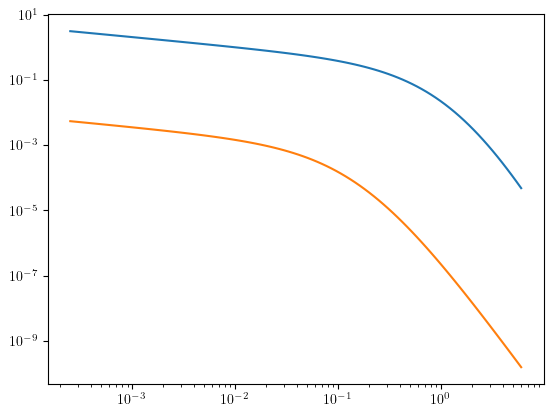

In [5]:
# B12_test.Pe_mat_physical.shape
pl.figure()
pl.plot(B12_test.r_array, B12_test.Pe_mat_physical[:,0,-1])
pl.plot(B12_test.r_array, B12_test.Pe_mat_physical[:,0,0])
pl.xscale('log')
pl.yscale('log')


In [6]:
from astropy.io import fits
df = fits.open(abs_path_data + '/websky/halo_input_wM200c_zmax2p5_minM200m_noh_5e13.fits')
# df[1].header
ra_all = df[1].data['ra']
dec_all = df[1].data['dec']
z_all = df[1].data['z']
M200c_all = df[1].data['M200c_wh']
M200m_all = df[1].data['M200m_wh']
vlos_all = df[1].data['vrad']
# c200c_all = df[1].data['c200c']
# indsel = np.where((M200m_all > 6e13) & (M200m_all < 5e15) & (z_all<2.5))[0]
indsel = np.where((M200m_all > 6e13) & (M200m_all < 5e15) & (z_all<2.5))[0]
print(len(indsel), len(M200c_all))
ra_all = ra_all[indsel]
dec_all = dec_all[indsel]
z_all = z_all[indsel]
M200c_all = M200c_all[indsel]
vlos_all = vlos_all[indsel]




1472528 4349354


In [7]:
# 10**np.amin(np.log10(M200m_all))
# 5e13*0.7

In [8]:
len(np.where((z_all > 0.2) & (z_all < 0.5))[0]), len(np.where((z_all > 0.5) & (z_all < 1.0))[0]), len(np.where((z_all > 1.0) & (z_all < 2.5))[0])




(332434, 707105, 390485)

In [9]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")




In [14]:
import pickle as pk
import jax
import scipy.interpolate as interp
import healpy as hp
import numpy as np
from multiprocessing import Pool, cpu_count
from astropy.io import fits
# import constants
import jax_cosmo.background as bkgrd
from godmax.get_sim_maps import get_sim_map
import h5py as h5


jax.clear_caches()
nside = 4096
sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/all_arxiv/mock_gen/maps_websky/'
# save_kszmap_fname = sdir + f'tSZ_sim_B12_testv3_nside_{nside}.pkl'
# save_kszmap_fname = sdir + f'kSZ_sim_B12_testv5_nside_{nside}_M200c_6e13_5e15.pkl'
save_kszmap_fname = sdir + f'kSZ_sim_B12_testv6_nside_{nside}_M200m_sel_5e13_5e15.pkl'
# if not os.path.exists(save_kszmap_fname):
halo_ra, halo_dec = ra_all, dec_all
halo_z = z_all
halo_m = M200c_all
# indsel = np.where((np.log10(halo_m) > 12.75))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
# indsel = np.where((halo_z < 0.95))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
print('number of halos: ', len(halo_m))
M_all = halo_m
ra_all = halo_ra
dec_all = halo_dec
z_all = halo_z
# vlos_all = np.zeros_like(z_all)
nsel = len(M_all)

# nh_max = 4e4
nh_max = 8e3
# nh_max = 2e4
# nh_max = 1e5
if nsel > nh_max:
    num_chunks = int(np.ceil(nsel / nh_max))
else:
    num_chunks = 1


kszmap_test = np.zeros(12*nside**2)
from tqdm import tqdm
for i in tqdm(range(num_chunks)):
# for i in range(1):
    # print(f'chunk {i+1}/{num_chunks}')
    if i == num_chunks - 1:
        M_all_chunk = M_all[int(i*nh_max):]
        ra_all_chunk = ra_all[int(i*nh_max):]
        dec_all_chunk = dec_all[int(i*nh_max):]
        z_all_chunk = z_all[int(i*nh_max):]
        vlos_all_chunk = vlos_all[int(i*nh_max):]
    else:
        M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
        ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
        dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
        z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
        vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

    mock_params_dict = {}
    mock_params_dict['halo_z'] = jnp.array(z_all_chunk)
    mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk)
    mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk)
    mock_params_dict['halo_M'] = jnp.array(M_all_chunk)
    mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk)
    mock_params_dict['nside'] = nside
    # mock_params_dict['get_ymap'] = True
    mock_params_dict['get_kSZmap'] = True

    halo_cat_scale_fac = 1./(1. + z_all_chunk)

    halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(B12_test.cosmo_jax,halo_cat_scale_fac) * 1e9
    mdef_delta=200
    halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z


    halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
    halo_cat_DA = bkgrd.angular_diameter_distance(B12_test.cosmo_jax,halo_cat_scale_fac)
    max_paint_R200c_factor = 3.


    # ra_all_np = np.clip(np.array(ra_all_chunk), 0., 360.)
    # dec_all_np = np.clip(np.array(dec_all_chunk), -90., 90.)
    ra_all_np = np.array(ra_all_chunk)
    dec_all_np = np.array(dec_all_chunk)
    z_all_np = np.array(z_all_chunk)
    halo_cat_R200c_np = np.array(halo_cat_R200c)
    halo_cat_DV_np = np.array(halo_cat_DA)
    halo_vlos_np = np.array(vlos_all_chunk)
    def process_halo(jhalo):
        vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)

        nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
        nearby_pix = hp.query_disc(mock_params_dict['nside'], vec, nearby_angle)

        nearby_ra, nearby_dec = hp.pix2ang(mock_params_dict['nside'], nearby_pix, lonlat=True)

        def hav(theta):
            return np.sin(theta / 2.) ** 2.

        ra1, dec1 = ra_all_np[jhalo] * np.pi / 180., dec_all_np[jhalo] * np.pi / 180.
        ra2, dec2 = nearby_ra * np.pi / 180., nearby_dec * np.pi / 180.
        theta = 2. * np.arcsin(np.sqrt(hav(dec1 - dec2) + np.cos(dec1) * np.cos(dec2) * hav(ra1 - ra2)))

        physical_distances_jhalo = halo_cat_DV_np[jhalo] * theta

        nearby_pix_array = np.array(nearby_pix)
        distances_pix_array = np.array(physical_distances_jhalo)
        logM_ind_array = np.ones(len(nearby_pix)) * np.log(M_all_chunk[jhalo])
        z_ind_array = np.ones(len(nearby_pix)) * z_all_chunk[jhalo]
        v_los_ind_array = np.ones(len(nearby_pix)) * halo_vlos_np[jhalo]
        return (nearby_pix_array, distances_pix_array, logM_ind_array, z_ind_array, v_los_ind_array, len(nearby_pix))

    def concatenate_results(results):
        # Pre-compute lengths for each part
        lengths = np.array([len(result[0]) for result in results])
        total_length = lengths.sum()

        # Pre-allocate arrays
        nearby_pix_all = np.empty(total_length, dtype=int)
        distances_pix_all = np.empty(total_length)
        logM_ind_all = np.empty(total_length)
        z_ind_all = np.empty(total_length)
        vlos_ind_all = np.empty(total_length)

        # Calculate start and end indices
        end_ind_all = np.cumsum(lengths)
        start_ind_all = np.roll(end_ind_all, 1)
        start_ind_all[0] = 0

        # Use array slicing for assignment
        for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
            nearby_pix_all[start:end] = result[0]
            distances_pix_all[start:end] = result[1]
            logM_ind_all[start:end] = result[2]
            z_ind_all[start:end] = result[3]
            vlos_ind_all[start:end] = result[4]

        return nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all


    # if __name__ == "__main__":
    with Pool(cpu_count()) as pool:
        results = pool.map(process_halo, range(len(z_all_chunk)))

    nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all = concatenate_results(results)

    mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
    mock_params_dict['pix_prop_all'] = jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all, vlos_ind_all]).T
    # mock_params_dict['start_ind'] = jnp.int32(jnp.array(start_ind_all))
    # mock_params_dict['end_ind'] = jnp.int32(jnp.array(end_ind_all))

    mock_map_test = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=B12_test)

    # find non-finite values and set them to zero
    kszmap_test += jnp.nan_to_num(mock_map_test.kszmap_final)
    jax.clear_caches()
    


saved = {}
saved['tszmap_test'] = kszmap_test
pk.dump(saved,open(save_kszmap_fname, 'wb'))


# else:
#     saved = pk.load(open(save_ymap_fname, 'rb'))
#     ymap_test = saved['ymap_test']



number of halos:  2110266


100%|██████████| 264/264 [39:49<00:00,  9.05s/it]


In [15]:
# fname = '/mnt/home/spandey/ceph/GODMAX/notebooks/all_arxiv/mock_gen/maps_websky/kSZ_sim_B12_testv5_nside_4096_M200c_6e13_5e15.pkl'
# saved = {}
# saved['tszmap_test'] = kszmap_test
# pk.dump(saved,open(fname, 'wb'))


In [16]:
# sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/mock_gen/maps_websky/'
# # save_kszmap_fname = sdir + f'tSZ_sim_B12_testv3_nside_{nside}.pkl'
# save_kszmap_fname = sdir + f'kSZ_sim_B12_testv4_nside_{nside}.pkl'
# saved = {}
# saved['kszmap_test'] = kszmap_test
# pk.dump(saved,open(save_kszmap_fname, 'wb'))


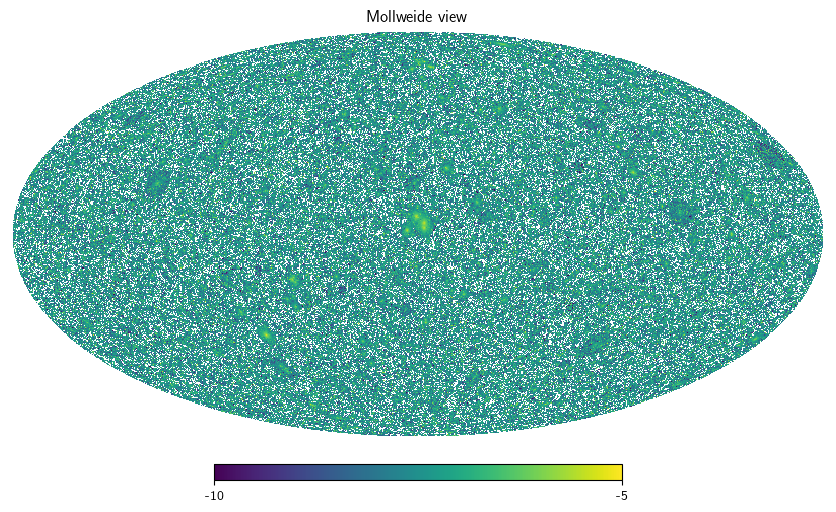

In [17]:
hp.mollview(np.log10(np.abs(kszmap_test)), min=-10, max=-5)



In [18]:
cl_ksz = hp.anafast(np.array(kszmap_test))


(4e-16, 3e-14)

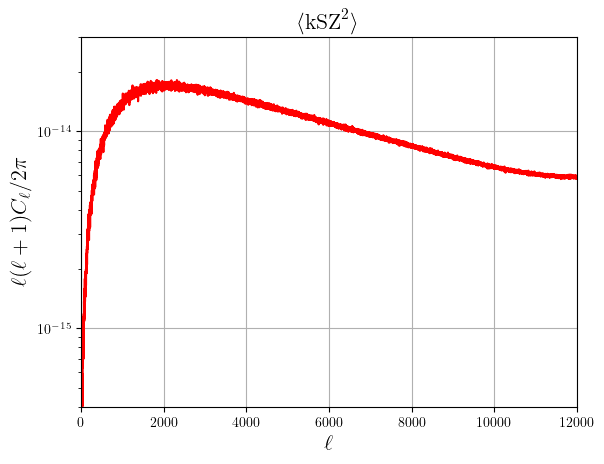

In [21]:
ell = np.arange(len(cl_ksz))
fac = ell * (ell + 1) / (2 * np.pi)
pl.figure()
pl.plot(fac * cl_ksz, color='r')
# pl.plot(fac * cl_ksz_websky / (2.725**2), color='b')
pl.yscale('log')
# pl.xscale('log')
pl.grid()
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$\ell(\ell+1)C_{\ell}/2\pi$', fontsize=16)
pl.title(r'$\langle {\rm kSZ}^2 \rangle$', fontsize=16)
pl.xlim(0, 12000)
pl.ylim(4e-16, 3e-14)



In [9]:
import pickle as pk
import jax
import scipy.interpolate as interp
import healpy as hp
import numpy as np
from multiprocessing import Pool, cpu_count
from astropy.io import fits
# import constants
import jax_cosmo.background as bkgrd
from godmax.get_sim_maps import get_sim_map
import h5py as h5


jax.clear_caches()
nside = 4096
sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/all_arxiv/mock_gen/maps_websky/'
# save_kszmap_fname = sdir + f'tSZ_sim_B12_testv3_nside_{nside}.pkl'
# save_taumap_fname = sdir + f'tau_map_sim_B12_testv5_nside_{nside}_M200c_6e13_5e15.pkl'
save_taumap_fname = sdir + f'tau_map_sim_B12_testv6_nside_{nside}_M200m_sel_5e13_5e15.pkl'
# if not os.path.exists(save_kszmap_fname):
halo_ra, halo_dec = ra_all, dec_all
halo_z = z_all
halo_m = M200c_all
# indsel = np.where((np.log10(halo_m) > 12.75))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
# indsel = np.where((halo_z < 0.95))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
print('number of halos: ', len(halo_m))
M_all = halo_m
ra_all = halo_ra
dec_all = halo_dec
z_all = halo_z
# vlos_all = np.zeros_like(z_all)
nsel = len(M_all)

# nh_max = 4e4
nh_max = 1e4
# nh_max = 2e4
# nh_max = 1e5
if nsel > nh_max:
    num_chunks = int(np.ceil(nsel / nh_max))
else:
    num_chunks = 1


taumap_test = np.zeros(12*nside**2)
from tqdm import tqdm
for i in tqdm(range(num_chunks)):
# for i in range(1):
    # print(f'chunk {i+1}/{num_chunks}')
    if i == num_chunks - 1:
        M_all_chunk = M_all[int(i*nh_max):]
        ra_all_chunk = ra_all[int(i*nh_max):]
        dec_all_chunk = dec_all[int(i*nh_max):]
        z_all_chunk = z_all[int(i*nh_max):]
        vlos_all_chunk = vlos_all[int(i*nh_max):]
    else:
        M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
        ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
        dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
        z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
        vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

    mock_params_dict = {}
    mock_params_dict['halo_z'] = jnp.array(z_all_chunk)
    mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk)
    mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk)
    mock_params_dict['halo_M'] = jnp.array(M_all_chunk)
    mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk)
    mock_params_dict['nside'] = nside
    # mock_params_dict['get_ymap'] = True
    mock_params_dict['get_taumap'] = True

    halo_cat_scale_fac = 1./(1. + z_all_chunk)

    halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(B12_test.cosmo_jax,halo_cat_scale_fac) * 1e9
    mdef_delta=200
    halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z


    halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
    halo_cat_DA = bkgrd.angular_diameter_distance(B12_test.cosmo_jax,halo_cat_scale_fac)
    max_paint_R200c_factor = 3.


    # ra_all_np = np.clip(np.array(ra_all_chunk), 0., 360.)
    # dec_all_np = np.clip(np.array(dec_all_chunk), -90., 90.)
    ra_all_np = np.array(ra_all_chunk)
    dec_all_np = np.array(dec_all_chunk)
    z_all_np = np.array(z_all_chunk)
    halo_cat_R200c_np = np.array(halo_cat_R200c)
    halo_cat_DV_np = np.array(halo_cat_DA)
    halo_vlos_np = np.array(vlos_all_chunk)
    def process_halo(jhalo):
        vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)

        nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
        nearby_pix = hp.query_disc(mock_params_dict['nside'], vec, nearby_angle)

        nearby_ra, nearby_dec = hp.pix2ang(mock_params_dict['nside'], nearby_pix, lonlat=True)

        def hav(theta):
            return np.sin(theta / 2.) ** 2.

        ra1, dec1 = ra_all_np[jhalo] * np.pi / 180., dec_all_np[jhalo] * np.pi / 180.
        ra2, dec2 = nearby_ra * np.pi / 180., nearby_dec * np.pi / 180.
        theta = 2. * np.arcsin(np.sqrt(hav(dec1 - dec2) + np.cos(dec1) * np.cos(dec2) * hav(ra1 - ra2)))

        physical_distances_jhalo = halo_cat_DV_np[jhalo] * theta

        nearby_pix_array = np.array(nearby_pix)
        distances_pix_array = np.array(physical_distances_jhalo)
        logM_ind_array = np.ones(len(nearby_pix)) * np.log(M_all_chunk[jhalo])
        z_ind_array = np.ones(len(nearby_pix)) * z_all_chunk[jhalo]
        v_los_ind_array = np.ones(len(nearby_pix)) * halo_vlos_np[jhalo]
        return (nearby_pix_array, distances_pix_array, logM_ind_array, z_ind_array, v_los_ind_array, len(nearby_pix))

    def concatenate_results(results):
        # Pre-compute lengths for each part
        lengths = np.array([len(result[0]) for result in results])
        total_length = lengths.sum()

        # Pre-allocate arrays
        nearby_pix_all = np.empty(total_length, dtype=int)
        distances_pix_all = np.empty(total_length)
        logM_ind_all = np.empty(total_length)
        z_ind_all = np.empty(total_length)
        vlos_ind_all = np.empty(total_length)

        # Calculate start and end indices
        end_ind_all = np.cumsum(lengths)
        start_ind_all = np.roll(end_ind_all, 1)
        start_ind_all[0] = 0

        # Use array slicing for assignment
        for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
            nearby_pix_all[start:end] = result[0]
            distances_pix_all[start:end] = result[1]
            logM_ind_all[start:end] = result[2]
            z_ind_all[start:end] = result[3]
            vlos_ind_all[start:end] = result[4]

        return nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all


    # if __name__ == "__main__":
    with Pool(cpu_count()) as pool:
        results = pool.map(process_halo, range(len(z_all_chunk)))

    nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all = concatenate_results(results)

    mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
    mock_params_dict['pix_prop_all'] = jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all, vlos_ind_all]).T
    # mock_params_dict['start_ind'] = jnp.int32(jnp.array(start_ind_all))
    # mock_params_dict['end_ind'] = jnp.int32(jnp.array(end_ind_all))

    mock_map_test = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=B12_test)

    # find non-finite values and set them to zero
    taumap_test += jnp.nan_to_num(mock_map_test.taumap_final)
    jax.clear_caches()
    


saved = {}
saved['tau_map_test'] = taumap_test
pk.dump(saved,open(save_taumap_fname, 'wb'))


# else:
#     saved = pk.load(open(save_ymap_fname, 'rb'))
#     ymap_test = saved['ymap_test']



number of halos:  2110266


100%|██████████| 212/212 [30:42<00:00,  8.69s/it]


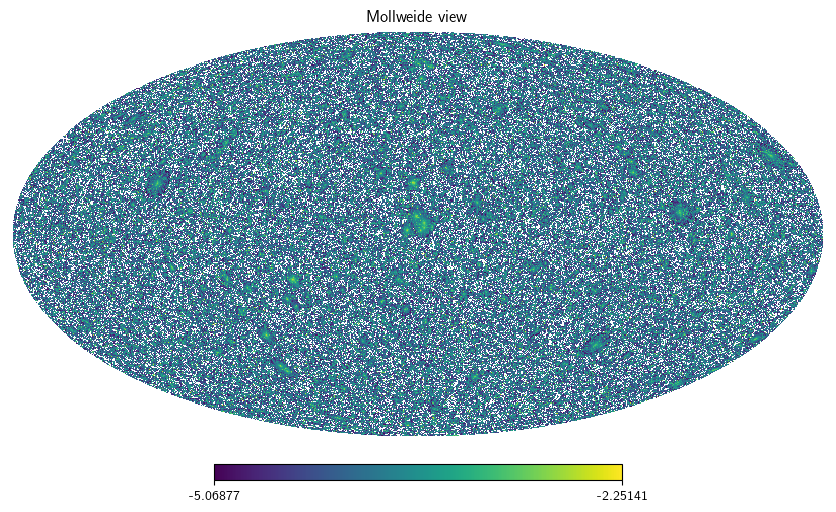

In [23]:
hp.mollview(np.log10(np.abs(taumap_test)))



In [12]:
cl_tau = hp.anafast(np.array(taumap_test))



(4e-10, 4e-08)

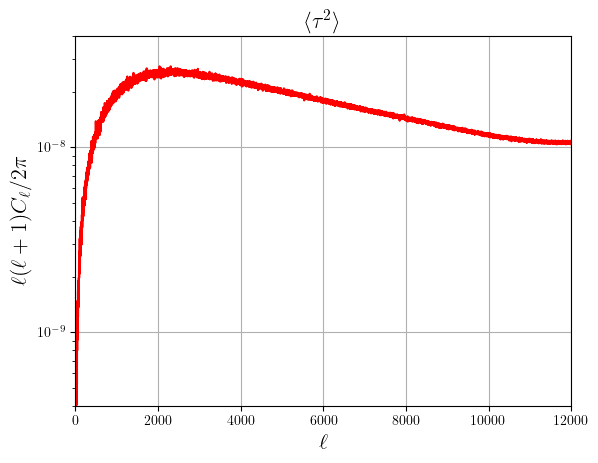

In [11]:
ell = np.arange(len(cl_tau))
fac = ell * (ell + 1) / (2 * np.pi)
pl.figure()
pl.plot(fac * cl_tau, color='r')
# pl.plot(fac * cl_ksz_websky / (2.725**2), color='b')
pl.yscale('log')
# pl.xscale('log')
pl.grid()
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$\ell(\ell+1)C_{\ell}/2\pi$', fontsize=16)
pl.title(r'$\langle {\rm \tau}^2 \rangle$', fontsize=16)
pl.xlim(0, 12000)
pl.ylim(4e-10, 4e-8)



In [10]:
import pickle as pk
import jax
import scipy.interpolate as interp
import healpy as hp
import numpy as np
from multiprocessing import Pool, cpu_count
from astropy.io import fits
# import constants
import jax_cosmo.background as bkgrd
from godmax.get_sim_maps import get_sim_map
import h5py as h5


jax.clear_caches()
nside = 4096
# nside = 1024
# nside = 2048
sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/all_arxiv/mock_gen/maps_websky/'
# save_kszmap_fname = sdir + f'tSZ_sim_B12_testv3_nside_{nside}.pkl'
# save_kszmap_fname = sdir + f'kSZ_sim_B12_testv5_nside_{nside}_M200c_6e13_5e15.pkl'
save_map_fname = sdir + f'tSZ_sim_B12_testv6_nside_{nside}_M200m_sel_6e13_5e15.pkl'
# if not os.path.exists(save_kszmap_fname):
halo_ra, halo_dec = ra_all, dec_all
halo_z = z_all
halo_m = M200c_all
# indsel = np.where((np.log10(halo_m) > 12.75))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
# indsel = np.where((halo_z < 0.95))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
print('number of halos: ', len(halo_m))
M_all = halo_m
ra_all = halo_ra
dec_all = halo_dec
z_all = halo_z
# vlos_all = np.zeros_like(z_all)
nsel = len(M_all)

nh_max = 5e3
# nh_max = 8e3
# nh_max = 2e5
# nh_max = 1e6
if nsel > nh_max:
    num_chunks = int(np.ceil(nsel / nh_max))
else:
    num_chunks = 1


ymap_test = np.zeros(12*nside**2)
from tqdm import tqdm
for i in tqdm(range(num_chunks)):
# for i in range(1):
    # print(f'chunk {i+1}/{num_chunks}')
    if i == num_chunks - 1:
        M_all_chunk = M_all[int(i*nh_max):]
        ra_all_chunk = ra_all[int(i*nh_max):]
        dec_all_chunk = dec_all[int(i*nh_max):]
        z_all_chunk = z_all[int(i*nh_max):]
        vlos_all_chunk = vlos_all[int(i*nh_max):]
    else:
        M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
        ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
        dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
        z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
        vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

    mock_params_dict = {}
    mock_params_dict['halo_z'] = jnp.array(z_all_chunk)
    mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk)
    mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk)
    mock_params_dict['halo_M'] = jnp.array(M_all_chunk)
    mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk)
    mock_params_dict['nside'] = nside
    mock_params_dict['get_ymap'] = True
    # mock_params_dict['get_kSZmap'] = True

    halo_cat_scale_fac = 1./(1. + z_all_chunk)

    halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(B12_test.cosmo_jax,halo_cat_scale_fac) * 1e9
    mdef_delta=200
    halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z


    halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
    halo_cat_DA = bkgrd.angular_diameter_distance(B12_test.cosmo_jax,halo_cat_scale_fac)
    max_paint_R200c_factor = 3.


    # ra_all_np = np.clip(np.array(ra_all_chunk), 0., 360.)
    # dec_all_np = np.clip(np.array(dec_all_chunk), -90., 90.)
    ra_all_np = np.array(ra_all_chunk)
    dec_all_np = np.array(dec_all_chunk)
    z_all_np = np.array(z_all_chunk)
    halo_cat_R200c_np = np.array(halo_cat_R200c)
    halo_cat_DV_np = np.array(halo_cat_DA)
    halo_vlos_np = np.array(vlos_all_chunk)
    def process_halo(jhalo):
        vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)

        nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
        nearby_pix = hp.query_disc(mock_params_dict['nside'], vec, nearby_angle)

        nearby_ra, nearby_dec = hp.pix2ang(mock_params_dict['nside'], nearby_pix, lonlat=True)

        def hav(theta):
            return np.sin(theta / 2.) ** 2.

        ra1, dec1 = ra_all_np[jhalo] * np.pi / 180., dec_all_np[jhalo] * np.pi / 180.
        ra2, dec2 = nearby_ra * np.pi / 180., nearby_dec * np.pi / 180.
        theta = 2. * np.arcsin(np.sqrt(hav(dec1 - dec2) + np.cos(dec1) * np.cos(dec2) * hav(ra1 - ra2)))

        physical_distances_jhalo = halo_cat_DV_np[jhalo] * theta

        nearby_pix_array = np.array(nearby_pix)
        distances_pix_array = np.array(physical_distances_jhalo)
        logM_ind_array = np.ones(len(nearby_pix)) * np.log(M_all_chunk[jhalo])
        z_ind_array = np.ones(len(nearby_pix)) * z_all_chunk[jhalo]
        v_los_ind_array = np.ones(len(nearby_pix)) * halo_vlos_np[jhalo]
        return (nearby_pix_array, distances_pix_array, logM_ind_array, z_ind_array, v_los_ind_array, len(nearby_pix))

    def concatenate_results(results):
        # Pre-compute lengths for each part
        lengths = np.array([len(result[0]) for result in results])
        total_length = lengths.sum()

        # Pre-allocate arrays
        nearby_pix_all = np.empty(total_length, dtype=int)
        distances_pix_all = np.empty(total_length)
        logM_ind_all = np.empty(total_length)
        z_ind_all = np.empty(total_length)
        vlos_ind_all = np.empty(total_length)

        # Calculate start and end indices
        end_ind_all = np.cumsum(lengths)
        start_ind_all = np.roll(end_ind_all, 1)
        start_ind_all[0] = 0

        # Use array slicing for assignment
        for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
            nearby_pix_all[start:end] = result[0]
            distances_pix_all[start:end] = result[1]
            logM_ind_all[start:end] = result[2]
            z_ind_all[start:end] = result[3]
            vlos_ind_all[start:end] = result[4]

        return nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all


    # if __name__ == "__main__":
    with Pool(cpu_count()) as pool:
        results = pool.map(process_halo, range(len(z_all_chunk)))

    nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all = concatenate_results(results)

    mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
    mock_params_dict['pix_prop_all'] = jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all, vlos_ind_all]).T
    # mock_params_dict['start_ind'] = jnp.int32(jnp.array(start_ind_all))
    # mock_params_dict['end_ind'] = jnp.int32(jnp.array(end_ind_all))

    mock_map_test = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=B12_test)

    # find non-finite values and set them to zero
    ymap_test += jnp.nan_to_num(mock_map_test.ymap_final)
    jax.clear_caches()
    


saved = {}
saved['ymap_test'] = ymap_test
pk.dump(saved,open(save_map_fname, 'wb'))


# else:
#     saved = pk.load(open(save_ymap_fname, 'rb'))
#     ymap_test = saved['ymap_test']



number of halos:  1472528


  4%|▍         | 13/295 [02:34<54:11, 11.53s/it] 2025-02-04 21:45:33.097316: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.50GiB (rounded to 1610612736)requested by op 
2025-02-04 21:45:33.097523: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] *******************************___****************************___***********************************
E0204 21:45:33.097541  954108 pjrt_stream_executor_client.cc:3045] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 1610612736 bytes. [tf-allocator-allocation-error='']
  4%|▍         | 13/295 [02:56<1:03:44, 13.56s/it]


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 1610612736 bytes.

In [ ]:
# # np.all(np.isfinite(mock_params_dict['pix_prop_all']))
# import healpy as hp
# import pickle as pk
# df = pk.load(open('/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/maps_websky/tSZ_sim_B12_testv6_nside_4096.pkl', 'rb')) 
# ymap_test = df['ymap_test']


In [ ]:
# df.keys()



In [7]:
cl_tsz = hp.anafast(np.array(ymap_test))



In [9]:
dfp = np.loadtxt('/mnt/home/spandey/ceph/GODMAX/data/planck_yyauto.txt')
ellp = dfp[:,0]
Dlp = dfp[:,1]





(10, 8000)

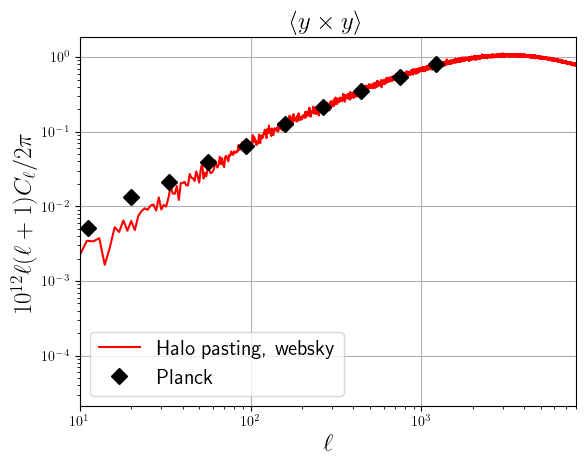

In [10]:
ell = np.arange(len(cl_tsz))
fac = 1e12 * ell * (ell + 1) / (2 * np.pi)
pl.figure()
pl.plot(fac * cl_tsz, color='r', label='Halo pasting, websky')
pl.plot(ellp, Dlp, color='k', marker='D', ms=8.0, ls='', label='Planck')
# pl.plot(fac * cl_ksz_websky / (2.725**2), color='b')
pl.yscale('log')
pl.xscale('log')
# pl.ylim(1e-14, 2e-12)
# pl.ylim(0.01, 2)
pl.grid()
pl.legend(fontsize=15)
pl.xlabel(r'$\ell$', fontsize=18)
pl.ylabel(r'$10^{12} \ell(\ell+1)C_{\ell}/2\pi$', fontsize=18)
pl.title(r'$\langle y \times y \rangle$', fontsize=18)
# pl.xlim(10, 4000)
pl.xlim(10, 8000)


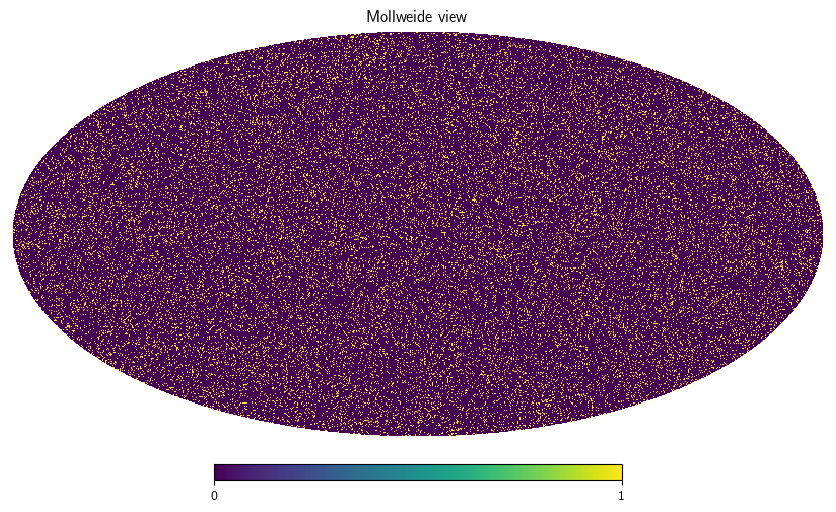

In [13]:
import numpy as np
import healpy as hp
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Generate 100 random points on a sphere with radius=5
num_points = 100000
radius = 5
phi = np.random.uniform(0, 2*np.pi, num_points)
theta = np.arccos(1 - 2*np.random.rand(num_points))
ra = np.degrees(phi)
dec = 90 - np.degrees(theta)

nside = 256
map_test = np.zeros(hp.nside2npix(nside))
pix = hp.ang2pix(nside, ra, dec, lonlat=True)
map_test[pix] = 1
hp.mollview(map_test)
